In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import warnings
import kagglehub
from sklearn.model_selection import train_test_split

path = kagglehub.dataset_download("shayanfazeli/heartbeat")
warnings.filterwarnings('ignore')
mitbih_train = pd.read_csv(path + '/mitbih_train.csv')
mitbih_test = pd.read_csv(path + '/mitbih_test.csv')

Linear model with MSE Loss on pytorch

In [2]:
class LinearModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        out = self.linear(x)
        return out

In [3]:
model = LinearModel(187,1)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [4]:
epoch_count = 150
data_train, data_val = train_test_split(np.array(mitbih_train), test_size= 0.2)
X_train, y_train = data_train[:, :-1], data_train[:, -1].astype(int)

X_val, y_val = data_val[:, :-1], data_val[:, -1].astype(int)

In [5]:
loss_5 = []
loss_val5 = []

for epoch in range(epoch_count):
    optimizer.zero_grad()
    outputs = model(torch.Tensor(X_train))
    loss = criterion(outputs, torch.Tensor(y_train).unsqueeze(1))
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        outputs_val = model(torch.Tensor(X_val))
        loss_val = criterion(outputs_val, torch.Tensor(y_val).unsqueeze(1))
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Loss_val: {loss_val.item():.4f}')
        loss_5.append(loss.item())
        loss_val5.append(loss_val.item())


Epoch 0, Loss: 1.8273, Loss_val: 1.5584
Epoch 5, Loss: 1.2435, Loss_val: 1.2101
Epoch 10, Loss: 1.1837, Loss_val: 1.1668
Epoch 15, Loss: 1.1603, Loss_val: 1.1448
Epoch 20, Loss: 1.1405, Loss_val: 1.1251
Epoch 25, Loss: 1.1218, Loss_val: 1.1066
Epoch 30, Loss: 1.1041, Loss_val: 1.0890
Epoch 35, Loss: 1.0874, Loss_val: 1.0723
Epoch 40, Loss: 1.0715, Loss_val: 1.0565
Epoch 45, Loss: 1.0564, Loss_val: 1.0414
Epoch 50, Loss: 1.0421, Loss_val: 1.0271
Epoch 55, Loss: 1.0285, Loss_val: 1.0135
Epoch 60, Loss: 1.0155, Loss_val: 1.0005
Epoch 65, Loss: 1.0031, Loss_val: 0.9881
Epoch 70, Loss: 0.9913, Loss_val: 0.9763
Epoch 75, Loss: 0.9801, Loss_val: 0.9650
Epoch 80, Loss: 0.9694, Loss_val: 0.9543
Epoch 85, Loss: 0.9591, Loss_val: 0.9440
Epoch 90, Loss: 0.9493, Loss_val: 0.9341
Epoch 95, Loss: 0.9399, Loss_val: 0.9247
Epoch 100, Loss: 0.9309, Loss_val: 0.9157
Epoch 105, Loss: 0.9223, Loss_val: 0.9070
Epoch 110, Loss: 0.9140, Loss_val: 0.8987
Epoch 115, Loss: 0.9061, Loss_val: 0.8907
Epoch 120, Los

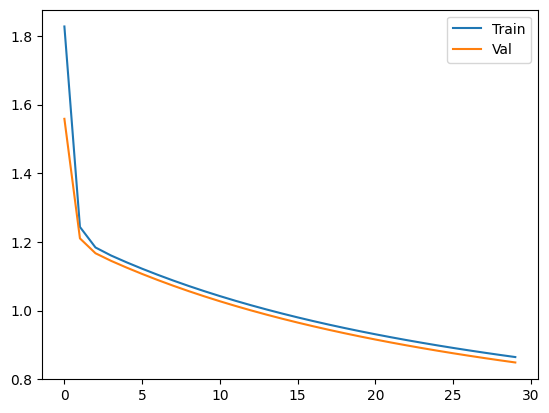

In [6]:
plt.plot(loss_5, label = 'Train')
plt.plot(loss_val5, label = 'Val')
plt.legend()

In [7]:
X_test, y_test = np.array(mitbih_test)[:, :-1], np.array(mitbih_test)[:, -1].astype(int)

In [8]:
model.eval()
with torch.no_grad():
    predicted = model(torch.Tensor(X_test))
    predicted_labels = (predicted >= 0.5).float()
    accuracy = (predicted_labels == torch.Tensor(y_test).unsqueeze(1)).sum().item() / torch.Tensor(y_test).unsqueeze(1).size(0)
print(f'Final Accuracy: {accuracy:.4f}')

Final Accuracy: 0.5903


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

In [10]:
model_tree = DecisionTreeClassifier()
model_boost = GradientBoostingClassifier()
model_forest = RandomForestClassifier()

In [ ]:
model_tree.fit(X_train,y_train)
model_boost.fit(X_train,y_train)
model_forest.fit(X_train,y_train)

In [ ]:
pred_tree = model_tree.predict(X_test)
pred_boost = model_boost.predict(X_test)
pred_forest = model_forest.predict(X_test)

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
print(f"f1 metric \nTree:{f1_score(pred_tree,y_test, average='micro')}\nBoosting:{f1_score(pred_boost,y_test, average='micro')}\nForest:{f1_score(pred_forest,y_test, average='micro')}")

f1 metric 
Tree:0.9499794436069617
Boosting:0.9638207482527066
Forest:0.9732310081768764
